In [1]:
import sys
sys.path.append("..")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from src.evaluate import evaluate_model

with open("../data/processed/processed_data.pkl", "rb") as f:
    data = pickle.load(f)

y_train = data["y_train"]
y_test = data["y_test"]

In [2]:
# KNN is distance-based, so using Variant A (no Risk_Channel leakage)
# with TF-IDF text features to start
X_train = data["A_train_tfidf"]
X_test = data["A_test_tfidf"]

print(X_train.shape, X_test.shape)

(11898, 126) (2975, 126)


In [3]:
print(X_train.isna().sum().sum())
print(X_train.dtypes.value_counts())

0
float64    117
bool         9
Name: count, dtype: int64


In [4]:
# hyperparameter search for k
# small grid, KNN gets slow with too many k values on 12k rows
param_grid = {"n_neighbors": [3, 5, 7, 9, 11, 15]}

knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, scoring="f1", cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

print("best k:", grid.best_params_)
print("best cv f1:", grid.best_score_)

best k: {'n_neighbors': 3}
best cv f1: 0.20394615834796423


In [5]:
# training final model with best k
best_knn = grid.best_estimator_

y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)[:, 1]

In [6]:

# evaluate model and save metrics and predictions     
results_row, cm = evaluate_model(
    model_name="knn",
    variant="A_tfidf",
    y_test=y_test,
    y_pred=y_pred,
    y_proba=y_proba,
    metrics_path="../results/metrics.csv",
    preds_path="../results/knn_predictions.csv"
)

Accuracy:  0.8235
Precision: 0.3333
Recall:    0.1488
F1-score:  0.2057
ROC-AUC:   0.5971
PR-AUC:    0.2120
Confusion Matrix:
 [[2382  136]
 [ 389   68]]


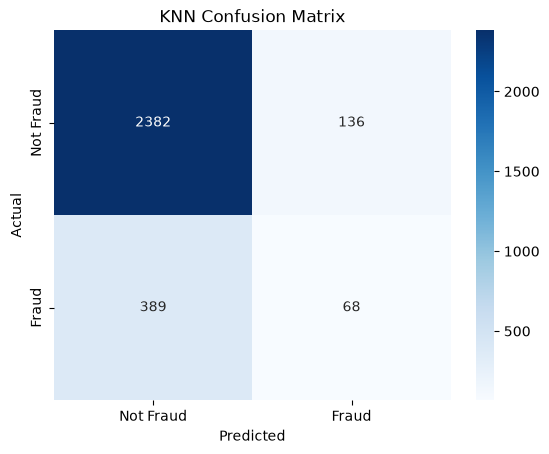

In [7]:
#confusion matrix

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()